<a href="https://colab.research.google.com/github/MayankJadhav784/TASK-15/blob/main/TASK%2015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [13]:
import pandas as pd

df = pd.read_csv('data.csv', encoding='ISO-8859-1')

In [14]:
df = df[df['CustomerID'].notnull()]

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [15]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  object 
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  float64
 6   CustomerID   397924 non-null  float64
 7   Country      397924 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Quantity': lambda x: (x * df.loc[x.index, 'UnitPrice']).sum()
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [18]:
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

In [19]:
def segment(rfm_score):
    if rfm_score == '444':
        return 'Champions'
    elif rfm_score[0] == '4':
        return 'Loyal'
    elif rfm_score[0] == '1':
        return 'At Risk'
    elif rfm_score[1] == '1':
        return 'Need Attention'
    else:
        return 'Others'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

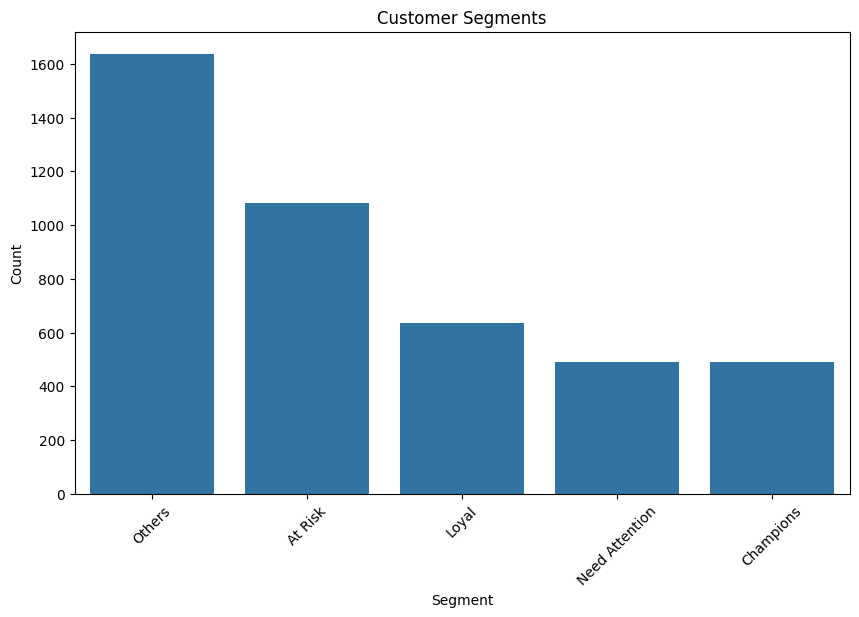

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [21]:
rfm.to_csv('rfm_segments.csv', index=False)

In [22]:
actions = {
    'Champions': [
        'Offer exclusive rewards and VIP programs.',
        'Give early access to new products.',
        'Encourage referrals and testimonials.'
    ],
    'Loyal': [
        'Provide personalized recommendations.',
        'Offer bundled discounts.',
        'Invite them to loyalty programs.'
    ],
    'At Risk': [
        'Send re-engagement emails with special offers.',
        'Collect feedback to understand drop-off.',
        'Offer time-limited promotions.'
    ],
    'Need Attention': [
        'Send reminder emails.',
        'Offer small incentives to return.',
        'Highlight trending products.'
    ],
    'Others': [
        'Run awareness campaigns.',
        'Offer first-time buyer discounts.',
        'Educate them about product benefits.'
    ]
}

with open('segment_actions.txt', 'w') as f:
    for segment, tips in actions.items():
        f.write(f"{segment}:\n")
        for tip in tips:
            f.write(f"- {tip}\n")
        f.write("\n")

In [24]:
from google.colab import files
files.download('segment_actions.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
from google.colab import files

files.download('rfm_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>